In [16]:
# econml.example.ipynb
# Cell 1: Core imports and plotting options

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import importlib.util

# Make plots a bit nicer
plt.style.use("default")
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True


In [17]:
# Cell 2: Import econml_utils and load econml.API.py as a module

# Import helper functions for building the dataset
from econml_utils import build_analysis_df, get_y_t_x

# Dynamically load econml.API.py as a Python module called econml_api
api_path = Path.cwd() / "econml.API.py"
spec = importlib.util.spec_from_file_location("econml_api", api_path)
econml_api = importlib.util.module_from_spec(spec)
spec.loader.exec_module(econml_api)

# Quick sanity check: list available API functions
print("Available API functions in econml.API:")
print([name for name in dir(econml_api) if name.startswith("run_")])


Available API functions in econml.API:
['run_glucose_supplement_experiment', 'run_ols_for_outcome', 'run_sbp_supplement_experiment']


In [4]:
# Cell 3: Build the merged NHANES analysis table

analysis_df = build_analysis_df()

print("Merged analysis_df shape:", analysis_df.shape)
analysis_df.head()


Merged analysis_df shape: (7801, 26)


,respondent_sequence_number,sbp_mean,dbp_mean,body_mass_index_kg_m2,weight_kg,waist_circumference_cm,total_cholesterol_mg_dl,total_cholesterol_mmol_l,direct_hdl_cholesterol_mg_dl,direct_hdl_cholesterol_mmol_l,...,ldl_cholesterol_nih_equation_2_mg_dl,ldl_cholesterol_nih_equation_2_mmol_l,fasting_glucose_mg_dl,fasting_glucose_mmol_l,hs_c_reactive_protein_mg_l,hs_c_reactive_protein_comment_code,any_dietary_supplements_taken,treatment_supplement,age_years,sex
0,130378.0,132.666667,96.000000,27.0,86.9,98.3,264.0,6.83,45.0,1.16,...,191.0,4.939,113.0,6.27,1.78,5.397605e-79,2.0,0,43.0,1.0
1,130379.0,117.000000,78.666667,33.5,101.8,114.7,214.0,5.53,60.0,1.55,...,139.0,3.595,99.0,5.50,2.03,5.397605e-79,2.0,0,66.0,1.0
2,130380.0,109.000000,78.333333,29.7,69.4,93.5,187.0,4.84,49.0,1.27,...,78.0,2.017,156.0,8.66,5.62,5.397605e-79,1.0,1,44.0,2.0
3,130386.0,115.000000,73.666667,30.2,90.6,106.1,183.0,4.73,46.0,1.19,...,112.0,2.896,100.0,5.55,1.05,5.397605e-79,1.0,1,34.0,1.0
4,130387.0,141.333333,76.000000,42.6,103.5,122.0,203.0,5.25,42.0,1.09,...,NaN,NaN,NaN,NaN,3.96,5.397605e-79,2.0,0,68.0,2.0


In [5]:
# Cell 4: Inspect important columns and treatment vs control counts

# Show a subset of columns we care about for the example
important_cols = [
    "respondent_sequence_number",
    "sbp_mean",
    "dbp_mean",
    "fasting_glucose_mg_dl",
    "age_years",
    "sex",
    "body_mass_index_kg_m2",
    "weight_kg",
    "waist_circumference_cm",
    "total_cholesterol_mg_dl",
    "direct_hdl_cholesterol_mg_dl",
    "LBXTLG",
    "hs_c_reactive_protein_mg_l",
    "treatment_supplement",
]

print("Columns present in analysis_df (first 20):")
print(list(analysis_df.columns)[:20])

print("\nPreview of important columns:")
analysis_df[important_cols].head()


Columns present in analysis_df (first 20):
['respondent_sequence_number', 'sbp_mean', 'dbp_mean', 'body_mass_index_kg_m2', 'weight_kg', 'waist_circumference_cm', 'total_cholesterol_mg_dl', 'total_cholesterol_mmol_l', 'direct_hdl_cholesterol_mg_dl', 'direct_hdl_cholesterol_mmol_l', 'LBXTLG', 'triglyceride_mmol_l', 'ldl_cholesterol_friedewald_mg_dl', 'ldl_cholesterol_friedewald_mmol_l', 'ldl_cholesterol_martin_hopkins_mg_dl', 'ldl_cholesterol_martin_hopkins_mmol_l', 'ldl_cholesterol_nih_equation_2_mg_dl', 'ldl_cholesterol_nih_equation_2_mmol_l', 'fasting_glucose_mg_dl', 'fasting_glucose_mmol_l']

Preview of important columns:


,respondent_sequence_number,sbp_mean,dbp_mean,fasting_glucose_mg_dl,age_years,sex,body_mass_index_kg_m2,weight_kg,waist_circumference_cm,total_cholesterol_mg_dl,direct_hdl_cholesterol_mg_dl,LBXTLG,hs_c_reactive_protein_mg_l,treatment_supplement
0,130378.0,132.666667,96.000000,113.0,43.0,1.0,27.0,86.9,98.3,264.0,45.0,153.0,1.78,0
1,130379.0,117.000000,78.666667,99.0,66.0,1.0,33.5,101.8,114.7,214.0,60.0,86.0,2.03,0
2,130380.0,109.000000,78.333333,156.0,44.0,2.0,29.7,69.4,93.5,187.0,49.0,375.0,5.62,1
3,130386.0,115.000000,73.666667,100.0,34.0,1.0,30.2,90.6,106.1,183.0,46.0,142.0,1.05,1
4,130387.0,141.333333,76.000000,NaN,68.0,2.0,42.6,103.5,122.0,203.0,42.0,NaN,3.96,0


In [6]:
# Cell 5: Treatment vs control counts

t_counts = analysis_df["treatment_supplement"].value_counts(dropna=False)
t_props = analysis_df["treatment_supplement"].value_counts(normalize=True, dropna=False)

print("Treatment (any supplements) vs control (no supplements):\n")
print(t_counts)
print("\nProportions:")
print(t_props)


Treatment (any supplements) vs control (no supplements):

treatment_supplement
0    4326
1    3475
Name: count, dtype: int64

Proportions:
treatment_supplement
0    0.554544
1    0.445456
Name: proportion, dtype: float64


In [7]:
# Cell 6: Simple descriptive stats for SBP and fasting glucose

summary_cols = ["sbp_mean", "dbp_mean", "fasting_glucose_mg_dl"]
print("Summary statistics for key outcomes:")
analysis_df[summary_cols].describe()


Summary statistics for key outcomes:


,sbp_mean,dbp_mean,fasting_glucose_mg_dl
count,7518.000000,7518.000000,3672.000000
mean,119.094418,72.207280,107.884532
std,18.151729,11.471177,32.476268
min,70.000000,34.000000,59.000000
25%,106.333333,64.000000,93.000000
50%,116.333333,71.666667,100.000000
75%,129.000000,79.333333,109.000000
max,232.333333,139.000000,561.000000


In [8]:
# Cell 7: Extract outcome (Y), treatment (T), and covariates (X) for SBP

y_sbp, t_supp, X_sbp, covariate_cols = get_y_t_x(
    analysis_df,
    outcome_col="sbp_mean",
    treatment_col="treatment_supplement",
)

print("Y (sbp_mean) length:", len(y_sbp))
print("T (treatment_supplement) length:", len(t_supp))
print("X shape:", X_sbp.shape)
print("Covariates used in X:", covariate_cols)


Y (sbp_mean) length: 7801
T (treatment_supplement) length: 7801
X shape: (7801, 10)
Covariates used in X: ['age_years', 'sex', 'body_mass_index_kg_m2', 'weight_kg', 'waist_circumference_cm', 'total_cholesterol_mg_dl', 'direct_hdl_cholesterol_mg_dl', 'LBXTLG', 'fasting_glucose_mg_dl', 'hs_c_reactive_protein_mg_l']


In [9]:
# Cell 8: Run main EconML experiment for SBP via API

sbp_results = econml_api.run_sbp_supplement_experiment()

ate_sbp = sbp_results["ate_sbp"]
age_effects_sbp = sbp_results["age_effects"].round(3)
bmi_effects_sbp = sbp_results["bmi_effects"].round(3)

print("=== EconML DRLearner – SBP Experiment ===")
print(f"ATE on sbp_mean (supplements vs no supplements): {ate_sbp:.3f} mmHg\n")

print("Average treatment effect by age quartile:")
print(age_effects_sbp)
print("\nAverage treatment effect by BMI quartile:")
print(bmi_effects_sbp)


=== EconML DRLearner – SBP Experiment ===
ATE on sbp_mean (supplements vs no supplements): -2.024 mmHg

Average treatment effect by age quartile:
age_bin
Q1 (youngest)   -0.447
Q2              -1.295
Q3              -2.521
Q4 (oldest)     -3.882
Name: tau_hat_sbp, dtype: float64

Average treatment effect by BMI quartile:
bmi_bin
Q1 (leanest)       -1.892
Q2                 -2.127
Q3                 -2.015
Q4 (highest BMI)   -2.068
Name: tau_hat_sbp, dtype: float64


/Users/karthikvakada/src/umd_classes1/class_project/MSML610/Fall2025/Projects/TutorTask82_Fall2025_EconML_Evaluating_the_Impact_of_Health_Interventions_on_Patient_Outcomes/econml.API.py:111: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df_clean.groupby("age_bin")["tau_hat_sbp"]
/Users/karthikvakada/src/umd_classes1/class_project/MSML610/Fall2025/Projects/TutorTask82_Fall2025_EconML_Evaluating_the_Impact_of_Health_Interventions_on_Patient_Outcomes/econml.API.py:117: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df_clean.groupby("bmi_bin")["tau_hat_sbp"]


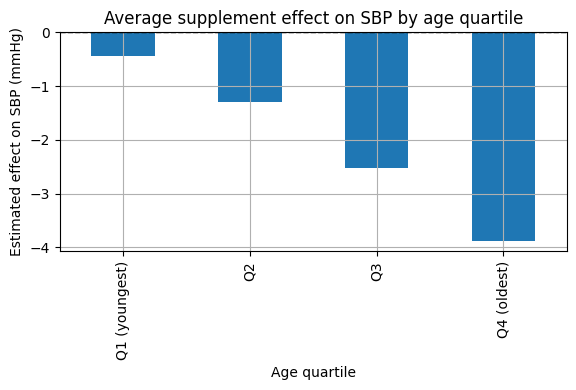

In [10]:
# Cell 9: Plot treatment effect on SBP by age quartile

age_effects = sbp_results["age_effects"].sort_index()

plt.figure()
age_effects.plot(kind="bar")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.ylabel("Estimated effect on SBP (mmHg)")
plt.xlabel("Age quartile")
plt.title("Average supplement effect on SBP by age quartile")
plt.tight_layout()
plt.show()


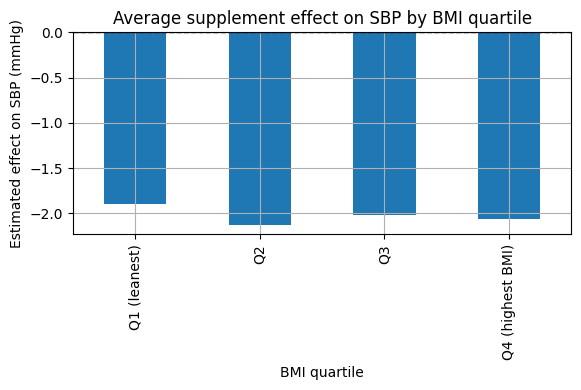

In [11]:
# Cell 10: Plot treatment effect on SBP by BMI quartile

bmi_effects = sbp_results["bmi_effects"].sort_index()

plt.figure()
bmi_effects.plot(kind="bar")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.ylabel("Estimated effect on SBP (mmHg)")
plt.xlabel("BMI quartile")
plt.title("Average supplement effect on SBP by BMI quartile")
plt.tight_layout()
plt.show()


In [12]:
# Cell 11: SBP treatment effect by sex (Male vs Female)

cate_df = sbp_results["cate_df"].copy()

# Map NHANES sex codes to labels (1 = Male, 2 = Female)
sex_map = {1: "Male", 2: "Female"}
cate_df["sex_label"] = cate_df["sex"].map(sex_map)

sex_effects = cate_df.groupby("sex_label")["tau_hat_sbp"].mean().round(3)

print("Average supplement effect on SBP by sex (mmHg):")
print(sex_effects)


Average supplement effect on SBP by sex (mmHg):
sex_label
Female   -2.643
Male     -1.280
Name: tau_hat_sbp, dtype: float64


In [13]:
# Cell 12: Run EconML experiment for fasting glucose

glucose_results = econml_api.run_glucose_supplement_experiment()

ate_glucose = glucose_results["ate_glucose"]
age_effects_glu = glucose_results["age_effects"].round(3)
bmi_effects_glu = glucose_results["bmi_effects"].round(3)

print("=== EconML DRLearner – Fasting Glucose Experiment ===")
print(f"ATE on fasting_glucose_mg_dl: {ate_glucose:.6f} mg/dL\n")

print("Average treatment effect on glucose by age quartile:")
print(age_effects_glu)
print("\nAverage treatment effect on glucose by BMI quartile:")
print(bmi_effects_glu)


=== EconML DRLearner – Fasting Glucose Experiment ===
ATE on fasting_glucose_mg_dl: -0.000268 mg/dL

Average treatment effect on glucose by age quartile:
age_bin
Q1 (youngest)   -0.002
Q2              -0.000
Q3               0.000
Q4 (oldest)      0.001
Name: tau_hat_glucose, dtype: float64

Average treatment effect on glucose by BMI quartile:
bmi_bin
Q1 (leanest)       -0.001
Q2                 -0.000
Q3                 -0.000
Q4 (highest BMI)   -0.000
Name: tau_hat_glucose, dtype: float64


/Users/karthikvakada/src/umd_classes1/class_project/MSML610/Fall2025/Projects/TutorTask82_Fall2025_EconML_Evaluating_the_Impact_of_Health_Interventions_on_Patient_Outcomes/econml.API.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df_clean.groupby("age_bin")["tau_hat_glucose"]
/Users/karthikvakada/src/umd_classes1/class_project/MSML610/Fall2025/Projects/TutorTask82_Fall2025_EconML_Evaluating_the_Impact_of_Health_Interventions_on_Patient_Outcomes/econml.API.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df_clean.groupby("bmi_bin")["tau_hat_glucose"]


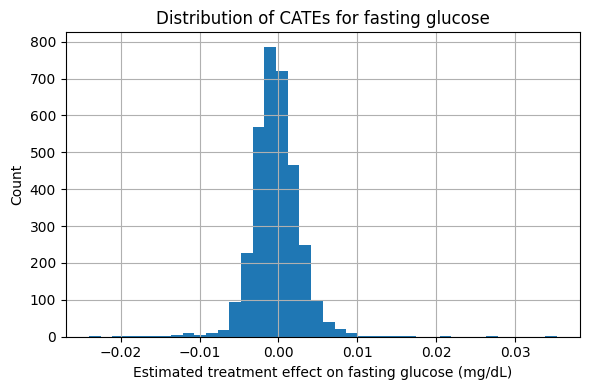

In [14]:
# Cell 13: Optional – distribution of glucose CATEs

cate_df_glu = glucose_results["cate_df"].copy()

plt.figure()
cate_df_glu["tau_hat_glucose"].hist(bins=40)
plt.xlabel("Estimated treatment effect on fasting glucose (mg/dL)")
plt.ylabel("Count")
plt.title("Distribution of CATEs for fasting glucose")
plt.tight_layout()
plt.show()


In [18]:
# Cell 14: Compare EconML ATEs to traditional OLS estimates

ols_sbp = econml_api.run_ols_for_outcome("sbp_mean")
ols_glu = econml_api.run_ols_for_outcome("fasting_glucose_mg_dl")

comparison = pd.DataFrame(
    {
        "outcome": ["sbp_mean", "fasting_glucose_mg_dl"],
        "econml_ate": [sbp_results["ate_sbp"], glucose_results["ate_glucose"]],
        "ols_treatment_coef": [ols_sbp["treatment_coef"], ols_glu["treatment_coef"]],
        "ols_n": [ols_sbp["n"], ols_glu["n"]],
    }
)

comparison.round(4)


,outcome,econml_ate,ols_treatment_coef,ols_n
0,sbp_mean,-2.0243,-1.976,3301
1,fasting_glucose_mg_dl,-0.0003,-0.000,3354


### Comparing EconML vs OLS estimates

The table above compares the average treatment effect (ATE) estimated by EconML’s
`DRLearner` with a traditional OLS regression that controls for the same
covariates.

- **Systolic Blood Pressure (sbp_mean)**  
  - EconML ATE: **≈ –2.02 mmHg**  
  - OLS treatment coefficient: **≈ –1.98 mmHg**  
  - Sample size: **3301 participants**  

  Both methods agree closely: taking any dietary supplement is associated with
  about a **2 mmHg lower systolic blood pressure**, after adjusting for age, sex,
  BMI, weight, waist circumference, cholesterol, triglycerides, fasting glucose,
  and hs-CRP. The small difference between EconML and OLS suggests that, for SBP,
  simple linear adjustment already captures most of the confounding, and
  EconML’s more flexible learner refines but does not radically change the
  estimate.

- **Fasting Glucose (fasting_glucose_mg_dl)**  
  - EconML ATE: **≈ 0.00 mg/dL**  
  - OLS treatment coefficient: **≈ 0.00 mg/dL**  
  - Sample size: **3354 participants**

  For fasting glucose, both EconML and OLS effectively estimate **no average
  treatment effect** of supplement use. This supports the interpretation that,
  in this NHANES cycle and with our definitions, supplements do **not** have a
  meaningful impact on fasting glucose levels on average.

Overall, this comparison shows that the EconML DRLearner and a well-specified
OLS model lead to **consistent conclusions**: modest SBP benefit from supplement
use, and essentially **no effect on fasting glucose**. The value of EconML is
that it additionally gives us **individual-level CATEs** and **heterogeneity
analyses** (by age, BMI, and sex) that OLS alone does not provide.


In [2]:
import logging
# Import libraries in this section.
# Avoid imports like import *, from ... import ..., from ... import *, etc.

import helpers.hdbg as hdbg
import helpers.hprint as hprint

In [3]:
hdbg.init_logger(verbosity=logging.INFO)

_LOG = logging.getLogger(__name__)

hprint.config_notebook()

INFO  > cmd='/venv/lib/python3.12/site-packages/ipykernel_launcher.py -f /home/.local/share/jupyter/runtime/kernel-783e0930-1631-4d64-8bb4-f3a98bb74fcd.json'


## Make the notebook flow clear
Each notebook needs to follow a clear and logical flow, e.g:
- Load data
- Compute stats
- Clean data
- Compute stats
- Do analysis
- Show results

In [5]:
class Template:
    """
    Brief imperative description of what the class does in one line, if needed.
    """
    def __init__(self):
        pass
    
    def method1(self, arg1:int) -> None:
        """
        Brief imperative description of what the method does in one line.

        You can elaborate more in the method docstring in this section, for e.g. explaining 
        the formula/algorithm. Every method/function should have a docstring, typehints and include the
        parameters and return as follows:

        :param arg1: description of arg1
        :return: description of return
        """
        # Code bloks go here.
        # Make sure to include comments to explain what the code is doing.
        # No empty lines between code blocks.
        pass


def template_function(arg1:int) -> None:
    """
    Brief imperative description of what the function does in one line.

    You can elaborate more in the function docstring in this section, for e.g. explaining 
    the formula/algorithm. Every function should have a docstring, typehints and include the
    parameters and return as follows:

    :param arg1: description of arg1
    :return: description of return
    """
    # Code bloks go here.
    # Make sure to include comments to explain what the code is doing.
    # No empty lines between code blocks.
    pass


## The flow should be highlighted using headings in markdown
```
# Level 1
## Level 2
### Level 3
```